In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

import pandas as pd

from Legacy.My_functions import *
from Legacy.Backtest import *

### Plotting Equity

In [2]:
df = get_stock_data("SPY", "2025-05-01", "2025-05-16", "Day", 1)

rsi = RSIStrategy()
rsi.generate_signal(df)

open      high       low   close  \
symbol timestamp                                                       
SPY    2025-05-01 04:00:00+00:00  560.37  564.0699  557.8600  558.47   
       2025-05-02 04:00:00+00:00  564.73  568.3800  562.3800  566.76   
       2025-05-05 04:00:00+00:00  562.57  566.6500  561.7000  563.51   
       2025-05-06 04:00:00+00:00  557.93  563.3476  556.9600  558.80   
       2025-05-07 04:00:00+00:00  560.15  563.8200  556.0400  561.15   
       2025-05-08 04:00:00+00:00  565.24  570.3100  561.7000  565.06   
       2025-05-09 04:00:00+00:00  566.48  567.5000  562.7637  564.34   
       2025-05-12 04:00:00+00:00  581.47  583.0000  577.0400  582.99   
       2025-05-13 04:00:00+00:00  583.41  589.0800  582.8400  586.84   
       2025-05-14 04:00:00+00:00  587.81  588.9800  585.5350  587.59   
       2025-05-15 04:00:00+00:00  585.56  590.9700  585.0969  590.46   

                                      volume RSI_14  signal_RSI_14_70_30  
symbol timestamp                                                          
SPY    2025-05-01 04:00:00+00:00  63186146.0   None                    0  
       2025-05-02 04:00:00+00:00  60717270.0   None                    0  
       2025-05-05 04:00:00+00:00  38659222.0   None                    0  
       2025-05-06 04:00:00+00:00  48264708.0   None                    0  
       2025-05-07 04:00:00+00:00  55733229.0   None                    0  
       2025-05-08 04:00:00+00:00  65130787.0   None                    0  
       2025-05-09 04:00:00+00:00  37603427.0   None                    0  
       2025-05-12 04:00:00+00:00  78993570.0   None                    0  
       2025-05-13 04:00:00+00:00  67947225.0   None                    0  
       2025-05-14 04:00:00+00:00  66283531.0   None                    0  
       2025-05-15 04:00:00+00:00  71268145.0   None                    0

TO DO:
Formal regression model

### Extra Confluence Functions

In [3]:
# df = get_stock_data("SPY", "2025-05-01", "2025-05-16", "Day", 1)

# def get_session_high_low(df, session_start, session_end):
#     session_data = df.between_time(session_start, session_end)
#     high = session_data['high'].max()
#     low = session_data['low'].min()
#     return high, low

# def is_sweep(current_price, previous_high, previous_low):
#     return current_price > previous_high or current_price < previous_low

# asian_high, asian_low = get_session_high_low(df, "20:00", "04:00")
# london_high, london_low = get_session_high_low(df, "04:00", "09:30")
# nyc_high, nyc_low = get_session_high_low(df, "09:30", "13:00")


# def detect_bos(df):
#     bos_points = []
#     for i in range(2, len(df)):
#         prev = df.iloc[i - 1]
#         curr = df.iloc[i]
#         if curr['high'] > prev['high'] and curr['low'] > prev['low']:
#             bos_points.append((df.index[i], 'bullish'))
#         elif curr['low'] < prev['low'] and curr['high'] < prev['high']:
#             bos_points.append((df.index[i], 'bearish'))
#     return bos_points

# def get_fib_retrace_entry(df, leg_start_time, leg_end_time):
#     leg_df = df.loc[leg_start_time:leg_end_time]
#     high = leg_df['high'].max()
#     low = leg_df['low'].min()
#     fib_50 = (high + low) / 2
#     for i in range(len(df)):
#         if abs(df['close'].iloc[i] - fib_50) / fib_50 < 0.001:  # within 0.1%
#             return df.index[i]
#     return None


### Highs/Lows Sweep

In [ ]:
def get_stock_data(symbol: str, start_date: str, end_date: str,
                   timeframe_unit: str = "Day", multiplier: int = 1):
                   
    if timeframe_unit not in SUPPORTED_TIMEFRAMES:
        raise ValueError(f"Unsupported timeframe unit: {timeframe_unit}")
    if multiplier not in SUPPORTED_TIMEFRAMES[timeframe_unit]:
        raise ValueError(f"Unsupported multiplier '{multiplier}' for '{timeframe_unit}'")

    unit_enum = TimeFrameUnit[timeframe_unit]
    alpaca_timeframe = TimeFrame(multiplier, unit_enum)

    request_params = StockBarsRequest(
        symbol_or_symbols=[symbol],
        timeframe=alpaca_timeframe,
        start=datetime.strptime(start_date, "%Y-%m-%d"),
        end=datetime.strptime(end_date, "%Y-%m-%d")
    )

    bars = client.get_stock_bars(request_params)
    df = bars.df

    # Handle both flat and MultiIndex column cases
    if isinstance(df.columns, pd.MultiIndex):
        if symbol in df.columns.levels[0]:
            df = df.xs(symbol, axis=1, level=0)
        else:
            raise KeyError(f"Symbol '{symbol}' not found in returned data columns.")
    
    # Check for required columns and raise helpful error if missing
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in data: {missing}\nAvailable columns: {df.columns.tolist()}")

    # Clean non-trading days
    df = df.dropna(subset=['open', 'high', 'low', 'close', 'volume'])

    # Drop fake/no-trade rows
    df = df[~(
        (df['open'] == df['high']) &
        (df['high'] == df['low']) &
        (df['low'] == df['close']) &
        (df['volume'] == 0)
    )]

    return df[required_cols]

In [4]:
def plot_candlesticks_with_trades(df, symbol: str, trade_log=None, sessions=None, show_pnl_labels=False):
    import matplotlib.pyplot as plt
    import numpy as np
    from mplfinance.original_flavor import candlestick_ohlc

    df = df.copy()

    # Handle MultiIndex and set timestamp
    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index(level=0, drop=True)
    df.index = pd.to_datetime(df.index)
    df['timestamp'] = df.index
    df = df.reset_index(drop=True)
    df['x'] = range(len(df))  # uniform x-axis

    # Plot setup
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 9))

    # === Candlesticks ===
    quotes = list(zip(
        df['x'],
        df['open'],
        df['high'],
        df['low'],
        df['close']
    ))
    candlestick_ohlc(ax1, quotes, width=0.6, colorup='green', colordown='red', alpha=0.8)

    # === Sessions (still using timestamp) ===
    if sessions:
        unique_days = df['timestamp'].dt.normalize().unique()

        for day in unique_days:
            for session_name, (start, end) in sessions.items():
                color = {"Asian": "purple", "London": "orange", "NYC": "cyan"}.get(session_name, "gray")

                start_time = pd.to_datetime(f"{day} {start}")
                end_time = pd.to_datetime(f"{day} {end}") if start < end else pd.to_datetime(f"{day + pd.Timedelta(days=1)} {end}")

                mask = (df['timestamp'] >= start_time) & (df['timestamp'] <= end_time) if start < end else \
                       ((df['timestamp'] >= start_time) | (df['timestamp'] <= end_time))

                session_df = df.loc[mask]
                if not session_df.empty:
                    high = session_df['high'].max()
                    low = session_df['low'].min()
                    x1 = session_df['x'].iloc[0]
                    x2 = session_df['x'].iloc[-1]
                    ax1.hlines(high, x1, x2, colors=color, linestyles='dashed', linewidth=1.2, label=f"{session_name} High" if day == unique_days[0] else "")
                    ax1.hlines(low, x1, x2, colors=color, linestyles='dotted', linewidth=1.2, label=f"{session_name} Low" if day == unique_days[0] else "")

    # === Trades ===
    if trade_log:
        x_lookup = {t: x for t, x in zip(df['timestamp'], df['x'])}
        for i in range(0, len(trade_log) - 1):
            entry = trade_log[i]
            if entry['action'] != 'entry':
                continue
            exit_ = next((t for t in trade_log[i+1:] if t['action'] in ['exit', 'forced_exit']), None)
            if not exit_:
                continue

            entry_time = entry['timestamp']
            exit_time = exit_['timestamp']
            if entry_time not in x_lookup or exit_time not in x_lookup:
                continue

            x1 = x_lookup[entry_time]
            x2 = x_lookup[exit_time]
            y1 = entry['entry_price']
            y2 = exit_['exit_price']
            pnl = exit_['pnl']
            color = 'green' if pnl >= 0 else 'red'
            marker = '^' if entry['side'] == 'long' else 'v'

            ax1.plot(x1, y1, marker=marker, color='blue', markersize=10, label='Entry' if i == 0 else "")
            ax1.plot(x2, y2, marker='x', color='black', markersize=10, label='Exit' if i == 0 else "")
            ax1.plot([x1, x2], [y1, y2], color=color, linewidth=2, alpha=0.6)

            if 'tp_price' in entry and 'sl_price' in entry:
                ax1.hlines(entry['tp_price'], x1, x2, colors='green', linestyles='dashed', linewidth=1, label='TP' if i == 0 else "")
                ax1.hlines(entry['sl_price'], x1, x2, colors='red', linestyles='dashed', linewidth=1, label='SL' if i == 0 else "")

            if show_pnl_labels:
                ax1.text(x2, y2, f'{pnl:.2f}', fontsize=10, ha='left', va='bottom', color=color)

    ax1.set_title(f'{symbol} Candlestick Chart with Trades & TP/SL')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # Ticks
    tick_interval = max(1, len(df) // 50)
    xticks = df['x'][::tick_interval]
    xticklabels = df['timestamp'].dt.strftime('%Y-%m-%d %H:%M')[::tick_interval]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticklabels, rotation=45)

    # Legend
    handles, labels = ax1.get_legend_handles_labels()
    if any(labels):
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [5]:
def generate_multi_session_sweep(df, sessions):
    df = df.copy()
    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index(level=0, drop=True)
    df.index = pd.to_datetime(df.index)
    df['signal'] = 0

    session_names = list(sessions.keys())
    session_high_lows = {}  # {date: {session_name: (high, low)}}

    # Step 1: Precompute all session highs/lows
    for day in df.index.normalize().unique():
        day_str = day.strftime('%Y-%m-%d')
        session_high_lows[day_str] = {}        

        for session_name, (start, end) in sessions.items():
            if start < end:
                if day_str in df.index.strftime('%Y-%m-%d'):
                    session_data = df.loc[day_str].between_time(start, end)
                else:
                    continue
            else:
                # Session crosses midnight
                next_day = (day + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                parts = []
                if day_str in df.index.strftime('%Y-%m-%d'):
                    parts.append(df.loc[day_str].between_time(start, "23:59"))
                if next_day in df.index.strftime('%Y-%m-%d'):
                    parts.append(df.loc[next_day].between_time("00:00", end))

                if not parts:
                    continue  # skip if no valid data

                session_data = pd.concat(parts)

            if not session_data.empty:
                high = session_data['high'].max()
                low = session_data['low'].min()
                session_high_lows[day_str][session_name] = (high, low)

    # Step 2: Check for sweeps of previous session in each session
    for i in range(1, len(df)):
        timestamp = df.index[i]
        date_str = timestamp.strftime('%Y-%m-%d')
        time_str = timestamp.strftime('%H:%M')

        for s_idx in range(1, len(session_names)):
            current_session = session_names[s_idx]
            prev_session = session_names[s_idx - 1]
            start, end = sessions[current_session]

            # Check if current time is within current session
            if (start < end and start <= time_str <= end) or (start > end and (time_str >= start or time_str <= end)):
                # Get prev session high/low
                prev_day = timestamp.date()
                if current_session == "Asian":
                    prev_day = timestamp.date() - pd.Timedelta(days=1)
                prev_day_str = prev_day.strftime('%Y-%m-%d')

                if prev_day_str in session_high_lows and prev_session in session_high_lows[prev_day_str]:
                    prev_high, prev_low = session_high_lows[prev_day_str][prev_session]

                    if df['high'].iloc[i] > prev_high:
                        df.iloc[i, df.columns.get_loc('signal')] = -1  # short
                    elif df['low'].iloc[i] < prev_low:
                        df.iloc[i, df.columns.get_loc('signal')] = 1  # long

    return df[['open', 'high', 'low', 'close', 'signal']]


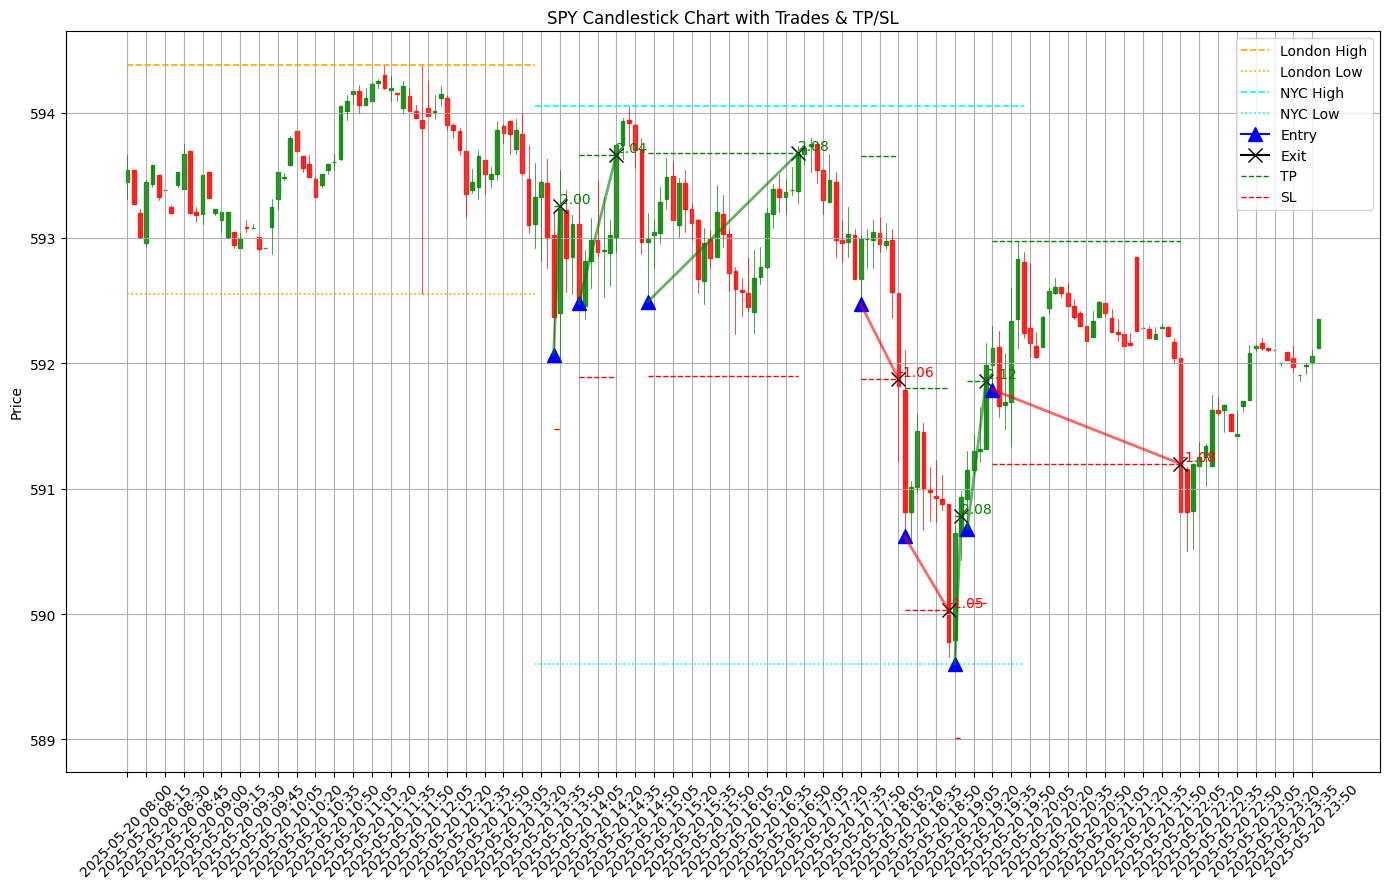

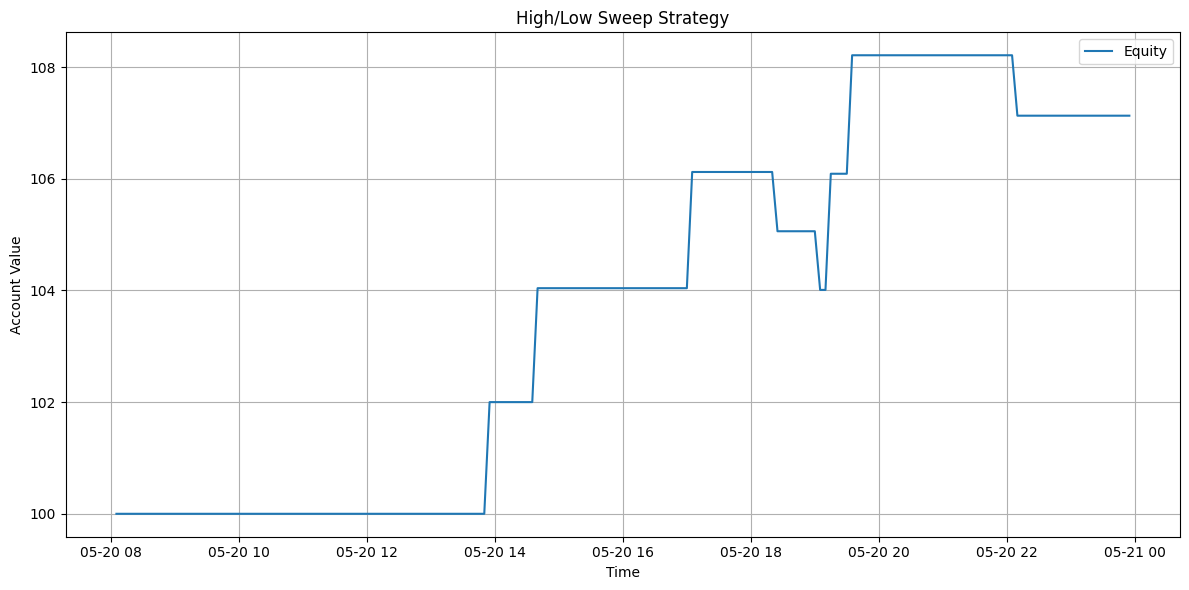

In [6]:
sessions = {
    "Asian": ("00:00", "07:00"),
    "London": ("08:00", "13:30"),
    "NYC": ("13:30", "20:00"),
}

df = get_stock_data("SPY", "2025-05-20", "2025-05-21", timeframe_unit="Minute", multiplier=5)
signal_df = generate_multi_session_sweep(df, sessions)

# print(signal_df.columns)

equity_curve, trade_log = backtest_with_rr_exit(signal_df, initial_cash=100, risk_per_trade=0.01, leverage=1, stop_pct=0.001)
plot_candlesticks_with_trades(df, symbol="SPY", trade_log=trade_log, sessions=sessions, show_pnl_labels=True)

# CHANGE IT SO THAT THE TP AND SL ARE TAKEN BASED ON IF THE WICK TOUCHES THESE LINES NOT THE CANDLE ITSELF

plt.figure(figsize=(12, 6))
plt.plot(equity_curve.index, equity_curve.values, label="Equity")
plt.title("High/Low Sweep Strategy")
plt.xlabel("Time")
plt.ylabel("Account Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
    

### Testing new file

In [7]:
# sessions = {
#     "Asian": ("00:00", "07:00"),
#     "London": ("08:00", "13:30"),
#     "NYC": ("13:30", "20:00"),
# }

# df = get_stock_data("SPY", "2025-05-01", "2025-05-15", timeframe_unit="Minute", multiplier=5)
# signal_df = generate_multi_session_sweep(df, sessions)

# # equity_curve, trade_log = backtest(signal_df, initial_cash=100)
# # plot_candlesticks(df, symbol="SPY", signal_df=signal_df)

# # equity_curve, trade_log = backtest_signals(signal_df, initial_cash=100, risk_per_trade=0.01, leverage=100)
# # plot_candlesticks_with_trades(df, symbol="SPY", trade_log=trade_log, sessions=sessions, show_pnl_labels=True)

# equity_curve, trade_log = backtest_with_rr_exit(signal_df, initial_cash=100, risk_per_trade=0.01, leverage=1, stop_pct=0.001)
# plot_candlesticks_with_trades(df, symbol="SPY", trade_log=trade_log, sessions=sessions, show_pnl_labels=True)


# plt.figure(figsize=(12, 6))
# plt.plot(equity_curve.index, equity_curve.values, label="Equity")
# plt.title("High/Low Sweep Strategy")
# plt.xlabel("Time")
# plt.ylabel("Account Value")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()
    